In [56]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

h, w = 512, 512
img_path = "../img/Baboon512.pgm"
save_path = "../results/"+img_path.split("/")[-1].split(".")[0]+".png"

'''
# Création Image
img = np.random.rand(h, w, 1).astype(np.float32) * 255
img = img.astype(np.uint8)
'''

# Load Image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512))

print(img)
print(img.shape)

[[ 10 160  60 ... 146 124 169]
 [196 128 111 ... 134 143 164]
 [138  84 125 ... 108 110  97]
 ...
 [ 87  90 103 ...  72  96  79]
 [ 94  85  85 ...  77  86 102]
 [ 77  72  70 ...   2   3   3]]
(512, 512)


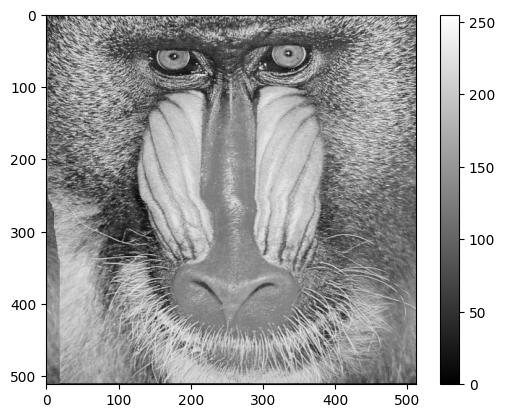

In [35]:
# Visualisation de l'image
plt.imshow(img, cmap=plt.cm.gray)
plt.colorbar()

In [36]:
# Calcul entropie
from scipy.stats import entropy

def calculer_entropie_scipy(image):
    histogramme, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    probas = histogramme / histogramme.sum()
    probas = probas[probas > 0]
    return entropy(probas, base=2)  # en bits

# Entropie initiale
entropie_originale = calculer_entropie_scipy(img)
print(entropie_originale)

7.296656463913346


In [37]:
# 1. Partitionner les blocs

size = 8  # taille des blocs

h, w = img.shape  # (512, 512) pour niveau de gris

# Pour image niveau de gris (2D) :
blocks = (
    img
    .reshape(h // size, size, w // size, size)  # (64, 8, 64, 8)
    .transpose(0, 2, 1, 3)                       # (64, 64, 8, 8)
    .reshape(-1, size, size)                     # (4096, 8, 8)
)

# `blocks` est un tableau de shape (nombre_de_blocs, size, size, channels)
# Chaque bloc est accessible individuellement :
premier_bloc = blocks[0]      # bloc en position (0,0)
deuxieme_bloc = blocks[1]     # prochain bloc (ligne par ligne)

print(blocks)
print(blocks.shape)

[[[ 10 160  60 ... 151  99  67]
  [196 128 111 ...  99  58  72]
  [138  84 125 ... 107  65  65]
  ...
  [ 94  89  83 ...  79 105  47]
  [200  47  56 ...  77 135  58]
  [181  36  56 ...  95 131  53]]

 [[ 36  77  84 ... 169 117  82]
  [ 49 102  66 ... 120  47  44]
  [ 52 118 116 ...  79  41  32]
  ...
  [ 51  79 107 ...  95 145  37]
  [ 67  70 120 ... 106 130  78]
  [ 64 108 179 ...  84 100 157]]

 [[161 201 133 ...  80  98 113]
  [120 162 139 ...  54  58  76]
  [ 56 129 115 ...  79  56  47]
  ...
  [ 47  53  66 ...  51  49  52]
  [ 68  60 111 ...  83  56  77]
  [ 60  65  78 ... 111 105  94]]

 ...

 [[140 148 156 ... 100  92  88]
  [117 139 150 ... 108  98  77]
  [131 130 140 ... 117  99 118]
  ...
  [124 107 117 ... 104  94 109]
  [107 108  96 ... 102 106  89]
  [  3   1   1 ...   0   0   1]]

 [[ 92 107 124 ... 106 102 105]
  [ 94  97 113 ... 113  97  96]
  [ 95  98 123 ... 103  90  95]
  ...
  [102 110 113 ... 113 104  97]
  [ 94  96  93 ... 113  95  99]
  [  3   5   5 ...   6   5  

In [38]:
# 2. Réorganisation des bloc en vecteurs

vecteurs = []

for bloc in blocks:

    # Transformation du bloc NB×NB en vecteur de taille NB²
    vecteur = bloc.flatten()

    vecteurs.append(vecteur)

# Conversion en matrice numpy
vecteurs = np.array(vecteurs)

print(vecteurs.shape)
print("Nombre de vecteurs :", vecteurs.shape[0])
print("Taille des vecteurs :", vecteurs.shape[1])

# Vérification du premier vecteur
print("\nPremier vecteur :")
print(vecteurs[0])

(4096, 64)
Nombre de vecteurs : 4096
Taille des vecteurs : 64

Premier vecteur :
[ 10 160  60  53  97 151  99  67 196 128 111  43  74  99  58  72 138  84
 125  51  51 107  65  65  89  77 149 105  53  90 131  58  76  95 134 145
  54  83  96  82  94  89  83 175  66  79 105  47 200  47  56 147 143  77
 135  58 181  36  56 123 169  95 131  53]


In [39]:
# 3. Calcul de la matrice de covariance

# La matrice de covariance aura la shape Nb²*Nb²
matrice_covariance = np.cov(vecteurs, rowvar=False)

print("Shape de la matrice de covariance :", matrice_covariance.shape)

Shape de la matrice de covariance : (64, 64)


In [40]:
# 4. Diagonalisation de la matrice de covariance et calcul de ses vecteurs et valeurs propres

# Calcul des valeurs et vecteurs propres
valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_covariance)

print("Shape des valeurs propres :", valeurs_propres.shape)
print("Shape des vecteurs propres :", vecteurs_propres.shape)

Shape des valeurs propres : (64,)
Shape des vecteurs propres : (64, 64)


In [41]:
# 5. Tri des valeurs propres par ordre croissant et construction de la matrice de la transformée FI, ayant comme colonnes les vecteurs propres associés

# Tri des valeurs propres par ordre croissant
indices = np.argsort(valeurs_propres)

# Réorganisation des valeurs propres
valeurs_propres = valeurs_propres[indices]

# Réorganisation des vecteurs propres associés
vecteurs_propres = vecteurs_propres[:, indices]

# Construction de la matrice de transformée KL
FI = vecteurs_propres

# Vérification
print("Nombre de valeurs propres :", len(valeurs_propres))
print("Taille de FI :", FI.shape)

# Affichage des premières valeurs propres
print("\nPremières valeurs propres :")
print(valeurs_propres[:10])

Nombre de valeurs propres : 64
Taille de FI : (64, 64)

Premières valeurs propres :
[ 55.9928656   75.34696542  80.10852428  82.7599046   86.97158165
  95.97965899 113.26293232 117.16285808 120.72094325 125.22036676]


In [42]:
# 6. Calcul de la transformée KL pour chaque vecteur

# Transposée de FI (note: FI est déjà orthogonale, donc FI^T = FI⁻¹)
FI_T = FI.T

# Transformée KL de tous les vecteurs
transformee_KL = vecteurs @ FI_T

print("Shape de la transformée KL:", transformee_KL.shape)
print("Nombre de vecteurs transformés:", transformee_KL.shape[0])
print("Taille de chaque vecteur transformé:", transformee_KL.shape[1])

# Vérification du premier vecteur
print("\nPremier vecteur original:")
print(vecteurs[0])
print("\nPremier vecteur transformé KL:")
print(transformee_KL[0])

Shape de la transformée KL: (4096, 64)
Nombre de vecteurs transformés: 4096
Taille de chaque vecteur transformé: 64

Premier vecteur original:
[ 10 160  60  53  97 151  99  67 196 128 111  43  74  99  58  72 138  84
 125  51  51 107  65  65  89  77 149 105  53  90 131  58  76  95 134 145
  54  83  96  82  94  89  83 175  66  79 105  47 200  47  56 147 143  77
 135  58 181  36  56 123 169  95 131  53]

Premier vecteur transformé KL:
[ -29.35544666   16.0033904  -121.38515831   82.29111168    9.02405931
   63.80264516  -81.84457281 -124.69479722    0.78173601  -35.21952108
  109.71312378 -159.34550824  -51.43301627 -134.58371226   26.08832992
  154.72741269   72.0954778   -26.04886914   91.70445378  -37.02487395
  104.70779064  -69.7316338    52.67695944  145.09762668 -127.57695032
  -30.70556729  107.30374656 -125.51484391   18.59497912  -41.1721253
   52.97917145   63.54303826    0.49226478  176.18150625  -39.42741551
   77.02843977  111.51521504 -118.34433408   40.10917798 -133.683120

In [43]:
k = 35  # nombre de coefficients à GARDER (à modifier selon tes besoins)
nc = 64 - k  # nombre de coefficients à annuler (les plus petites valeurs propres)

print(f"Compression: {64} → {k} composantes (annulation de {nc} coefficients)")
print(f"Taux de compression: {k/64*100:.1f}% des données gardées")

Compression: 64 → 35 composantes (annulation de 29 coefficients)
Taux de compression: 54.7% des données gardées


In [44]:
# Annulation des nc premiers coefficients
Y_mod = transformee_KL.copy()
Y_mod[:, :nc] = 0

In [45]:
# Transformée de KL inverse
vecteurs_rec = Y_mod @ FI

In [33]:
# 7. Réorganisation des vecteurs transformés en blocs et reconstruction de l'image

# Reconstruction
image_rec = vecteurs_rec.reshape(64, 64, 8, 8).transpose(0, 2, 1, 3).reshape(512, 512)
image_rec = np.clip(image_rec, 0, 255).astype(np.uint8)

print("Shape de l'image reconstruite:", image_rec.shape)  # (512, 512)

Shape de l'image reconstruite: (512, 512)


KeyError: 'PGM'

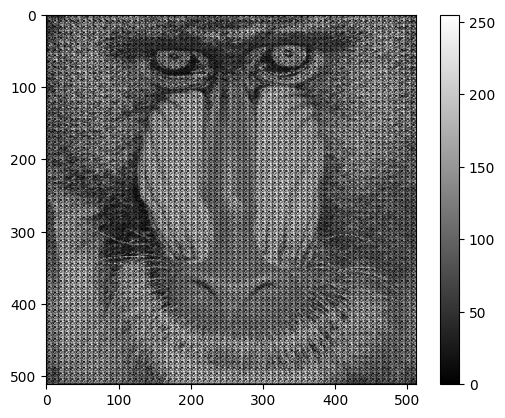

In [ ]:
# Visualisation finale
plt.imshow(image_rec, cmap=plt.cm.gray)
plt.colorbar()
plt.imsave(save_path, image_rec)

In [16]:
# Entropie finale
entropie_transformee = calculer_entropie_scipy(image_rec)
print(entropie_transformee)

7.446498112460298
